In [1]:
import os
import cv2
import pickle
import numpy as np
from tqdm import tqdm
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [2]:
import os
import numpy as np
import matplotlib.pyplot as plt
import cv2
from PIL import Image, ImageOps

import tensorflow as tf
from tensorflow.keras.models import Sequential, Model, model_from_json
from tensorflow.keras.layers import (
    Input, BatchNormalization, ReLU, ELU, Dropout, Conv2D, Dense, MaxPool2D, 
    AvgPool2D, GlobalAvgPool2D, Concatenate, Flatten, Activation, SeparableConv2D, 
    UpSampling2D, GlobalAveragePooling2D, ZeroPadding2D, MaxPooling2D
)
from tensorflow.keras.preprocessing.image import (
    ImageDataGenerator, array_to_img, img_to_array, load_img
)
from tensorflow.keras.callbacks import EarlyStopping, TensorBoard
from tensorflow.keras.optimizers import SGD, RMSprop
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.regularizers import l2

In [3]:
DATA_DIR = 'd:/kabbo_capstone/Dataset'
TRAIN_DATA_DIR = os.path.join(DATA_DIR, 'train')
TEST_DATA_DIR = os.path.join(DATA_DIR, 'valid')

In [4]:
IMG_SIZE = 128
CATEGORIES = []
for i in os.listdir(TRAIN_DATA_DIR):
    CATEGORIES.append(i)
print(CATEGORIES)

['Agaricus_Bisporus_Edible', 'Agaricus_Edible', 'Amanita_Toxic', 'Calocybe_Indica_Edible', 'Deathcap_Toxic', 'Oyster_Edible']


In [5]:
classes = len(CATEGORIES)
classes

6

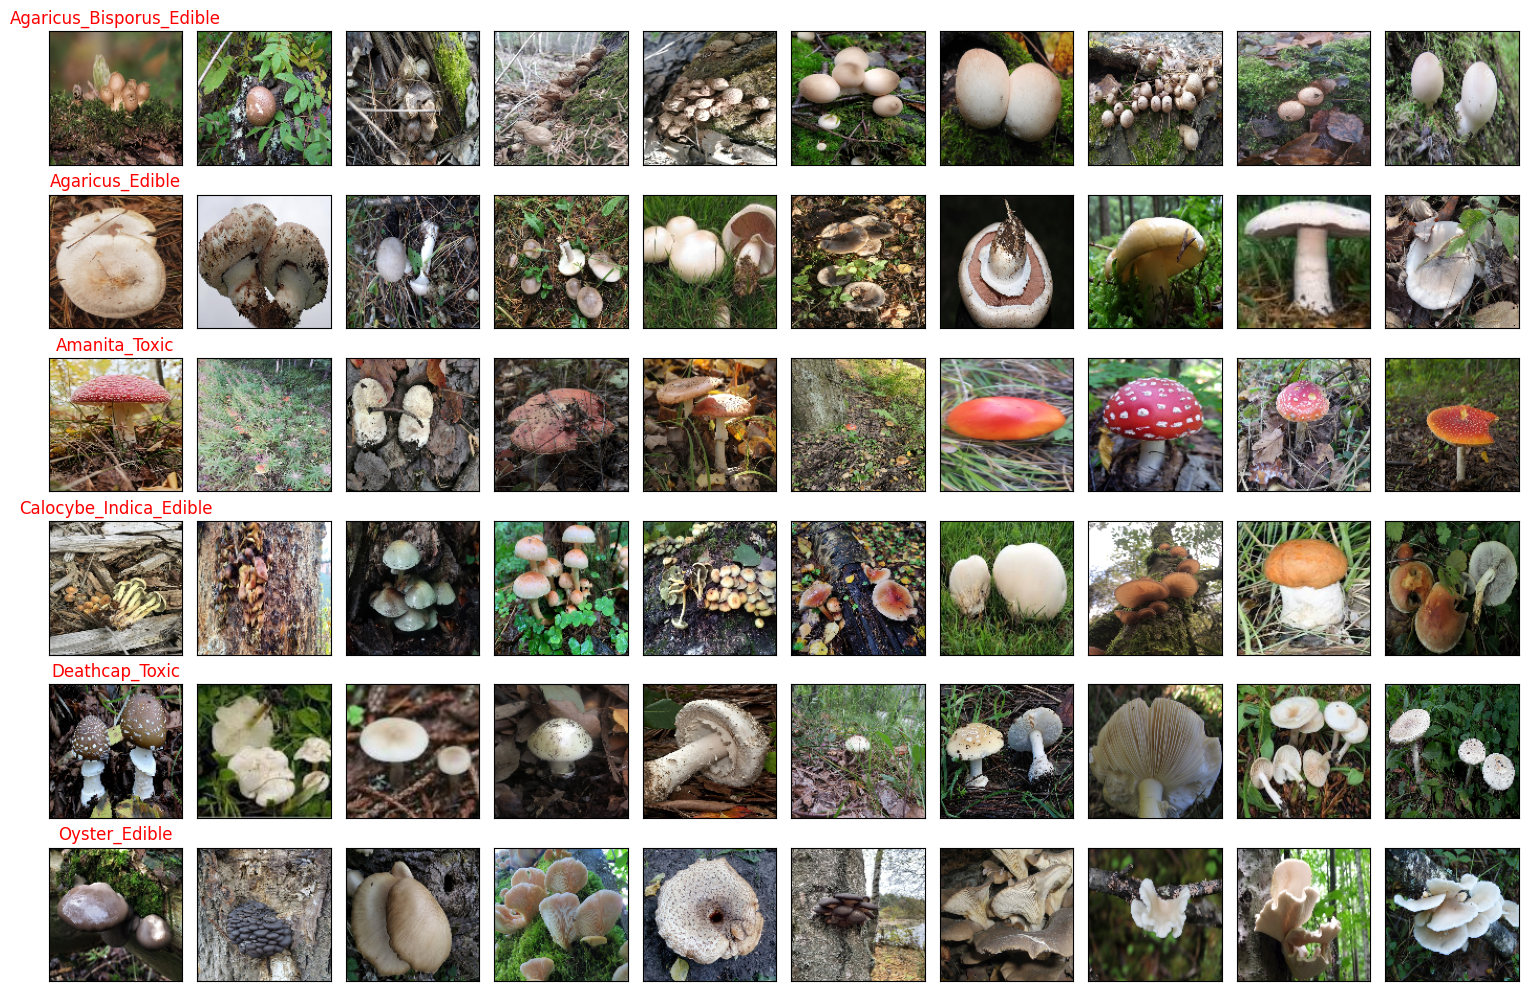

In [7]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
import random

# Define the fixed image size
fixed_size = (128, 128)

plt.figure(figsize=(15, 10), facecolor='white')
i = 1
num_images_per_class = 10

for c in CATEGORIES:
    path = os.path.join(TRAIN_DATA_DIR, c)
    image_list = os.listdir(path)
    if len(image_list) < num_images_per_class:
        continue
    random.shuffle(image_list)
    image_list = image_list[:num_images_per_class]

    for img_name in image_list:
        img_array = cv2.imread(os.path.join(path, img_name))
        img_array = cv2.cvtColor(img_array, cv2.COLOR_BGR2RGB)

        # Resize the image to the fixed size
        img_resized = cv2.resize(img_array, fixed_size)

        plt.subplot(len(CATEGORIES), num_images_per_class, i)
        plt.imshow(img_resized)

        if i % num_images_per_class == 1:
            plt.title(c, color='red')

        plt.xticks([])
        plt.yticks([])
        i += 1

plt.tight_layout()
plt.show()


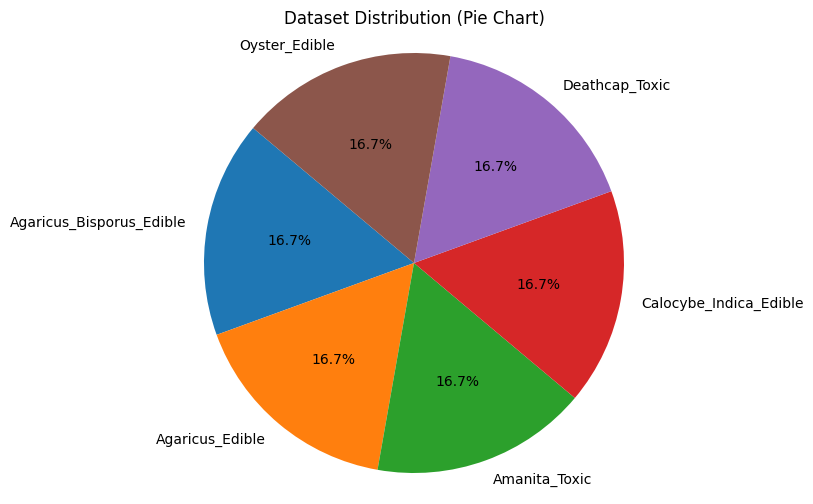

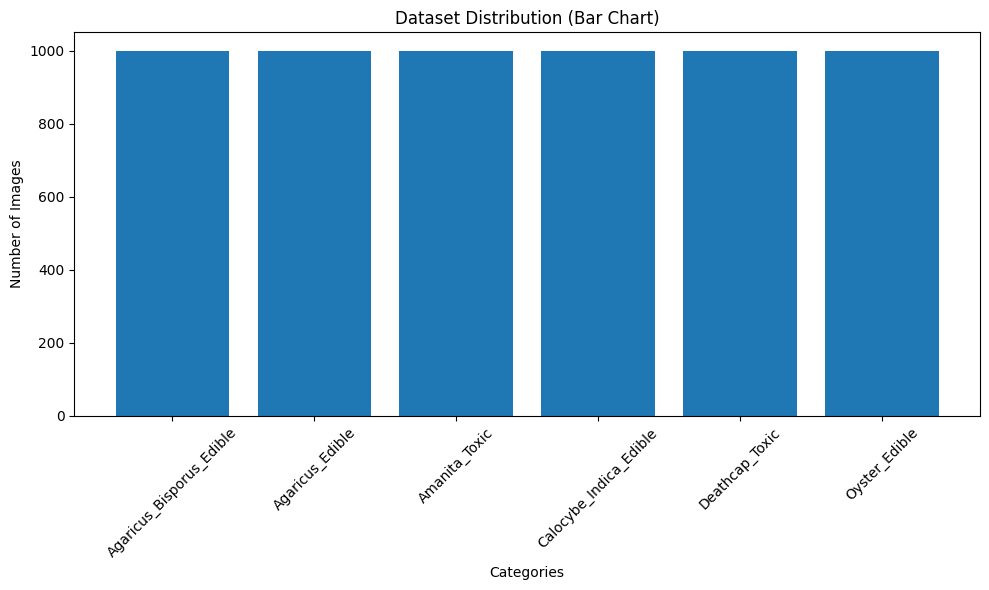

In [9]:
category_counts = {}
for category in CATEGORIES:
    category_path = os.path.join(TRAIN_DATA_DIR, category)
    num_images = len(os.listdir(category_path))
    category_counts[category] = num_images


plt.figure(figsize=(10, 6), facecolor='white')
plt.pie(category_counts.values(), labels=category_counts.keys(), autopct='%1.1f%%', startangle=140)
plt.title('Dataset Distribution (Pie Chart)')
plt.axis('equal')
plt.show()

plt.figure(figsize=(10, 6))
plt.bar(category_counts.keys(), category_counts.values())
plt.xlabel('Categories')
plt.ylabel('Number of Images')
plt.title('Dataset Distribution (Bar Chart)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [10]:
training_data = []

for c in CATEGORIES:
    path = os.path.join(TRAIN_DATA_DIR, c)
    class_num = CATEGORIES.index(c)
    for img in tqdm(os.listdir(path)):
        try:
            img_array = cv2.imread(os.path.join(path, img))
            img_resized = cv2.resize(img_array, (IMG_SIZE, IMG_SIZE))
            training_data.append([img_resized, class_num])
        except Exception as e:
            pass

print(len(training_data))

100%|██████████| 1000/1000 [00:21<00:00, 46.05it/s]

6000


In [11]:
test_data = []

for c in CATEGORIES:
    path = os.path.join(TEST_DATA_DIR, c)
    class_num = CATEGORIES.index(c)
    for img in tqdm(os.listdir(path)):
        try:
            img_array = cv2.imread(os.path.join(path, img))
            img_resized = cv2.resize(img_array, (IMG_SIZE, IMG_SIZE))
            test_data.append([img_resized, class_num])
        except Exception as e:
            pass

print(len(test_data))

100%|██████████| 200/200 [00:03<00:00, 53.72it/s]

1200


In [12]:
X_train = []
Y_train = []

for img, label in training_data:
    X_train.append(img)
    Y_train.append(label)

X_train = np.array(X_train).astype('float32').reshape(-1, IMG_SIZE, IMG_SIZE, 3)
Y_train = np.array(Y_train)

print(f"X_train= {X_train.shape} Y_train= {Y_train.shape}")

X_train= (6000, 128, 128, 3) Y_train= (6000,)


In [13]:
X_test = []
Y_test = []

for features,label in test_data:
    X_test.append(features)
    Y_test.append(label)

X_test = np.array(X_test).astype('float32').reshape(-1, IMG_SIZE, IMG_SIZE, 3)
Y_test = np.array(Y_test)

print(f"X_test= {X_test.shape} Y_test= {Y_test.shape}")
X_train, X_test = X_train / 255.0, X_test / 255.0

X_test= (1200, 128, 128, 3) Y_test= (1200,)


In [14]:
import efficientnet.tfkeras as efn
import tensorflow as tf

# Load the EfficientNetB0 model with ImageNet weights, without the top layer
enet = efn.EfficientNetB0(
    input_shape=(128, 128, 3),
    weights='imagenet',
    include_top=False
)

# Freeze the layers of the EfficientNetB0 model
for layer in enet.layers:
    layer.trainable = False

# Add custom layers on top of the EfficientNetB0 base model
x = enet.output
x = tf.keras.layers.GlobalMaxPooling2D()(x)
x = tf.keras.layers.Dense(256, activation='relu')(x)
x = tf.keras.layers.BatchNormalization()(x)
x = tf.keras.layers.Dropout(0.5)(x)
y = tf.keras.layers.Dense(classes, activation='softmax')(x)  # 'classes' should be defined

# Create the final model
e_model_b0 = tf.keras.Model(inputs=enet.input, outputs=y)

# Compile the model
e_model_b0.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=5e-4),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [15]:
efficientnet_b0 = e_model_b0.fit(x=X_train, y=Y_train, epochs=50, validation_data=(X_test, Y_test), batch_size=64)

Epoch 1/50
94/94 ━━━━━━━━━━━━━━━━━━━━ 131s 1s/step - accuracy: 0.4151 - loss: 1.8435 - val_accuracy: 0.7408 - val_loss: 0.7244
Epoch 2/50
94/94 ━━━━━━━━━━━━━━━━━━━━ 86s 917ms/step - accuracy: 0.6426 - loss: 1.0271 - val_accuracy: 0.8025 - val_loss: 0.5756
Epoch 3/50
94/94 ━━━━━━━━━━━━━━━━━━━━ 84s 894ms/step - accuracy: 0.6962 - loss: 0.8404 - val_accuracy: 0.8092 - val_loss: 0.5435
Epoch 4/50
94/94 ━━━━━━━━━━━━━━━━━━━━ 87s 921ms/step - accuracy: 0.7234 - loss: 0.7596 - val_accuracy: 0.8325 - val_loss: 0.4692
Epoch 5/50
94/94 ━━━━━━━━━━━━━━━━━━━━ 89s 949ms/step - accuracy: 0.7521 - loss: 0.6845 - val_accuracy: 0.8533 - val_loss: 0.4423
Epoch 6/50
94/94 ━━━━━━━━━━━━━━━━━━━━ 138s 910ms/step - accuracy: 0.7570 - loss: 0.6462 - val_accuracy: 0.8592 - val_loss: 0.3979
Epoch 7/50
94/94 ━━━━━━━━━━━━━━━━━━━━ 143s 920ms/step - accuracy: 0.7747 - loss: 0.6062 - val_accuracy: 0.8858 - val_loss: 0.3510
Epoch 8/50
94/94 ━━━━━━━━━━━━━━━━━━━━ 87s 925ms/step - accuracy: 0.7926 - loss: 0.5531 - val_accu

In [16]:
testX_arg = np.argmax(Y_test)
y_pred = np.argmax(e_model_b0.predict(X_test), axis=1)
y_true = np.argmax(Y_test)
print(y_pred)
print(y_pred.shape)

38/38 ━━━━━━━━━━━━━━━━━━━━ 28s 545ms/step
[0 0 0 ... 5 5 5]
(1200,)


In [17]:
from sklearn import datasets
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
cm = confusion_matrix(Y_test,y_pred)
cm

array([[199,   0,   0,   1,   0,   0],
       [  0, 199,   0,   0,   1,   0],
       [  0,   0, 200,   0,   0,   0],
       [  1,   1,   0, 198,   0,   0],
       [  0,   0,   0,   0, 200,   0],
       [  1,   0,   0,   0,   0, 199]], dtype=int64)

In [19]:
print(classification_report(Y_test, y_pred,  digits=7,target_names = CATEGORIES))

                          precision    recall  f1-score   support

Agaricus_Bisporus_Edible  0.9900498 0.9950000 0.9925187       200
         Agaricus_Edible  0.9950000 0.9950000 0.9950000       200
           Amanita_Toxic  1.0000000 1.0000000 1.0000000       200
  Calocybe_Indica_Edible  0.9949749 0.9900000 0.9924812       200
          Deathcap_Toxic  0.9950249 1.0000000 0.9975062       200
           Oyster_Edible  1.0000000 0.9950000 0.9974937       200

                accuracy                      0.9958333      1200
               macro avg  0.9958416 0.9958333 0.9958333      1200
            weighted avg  0.9958416 0.9958333 0.9958333      1200



In [20]:
import pandas as pd
cm = pd.DataFrame(cm , index = CATEGORIES , columns = CATEGORIES)

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns

<Axes: title={'center': 'Confusion Matrix'}>

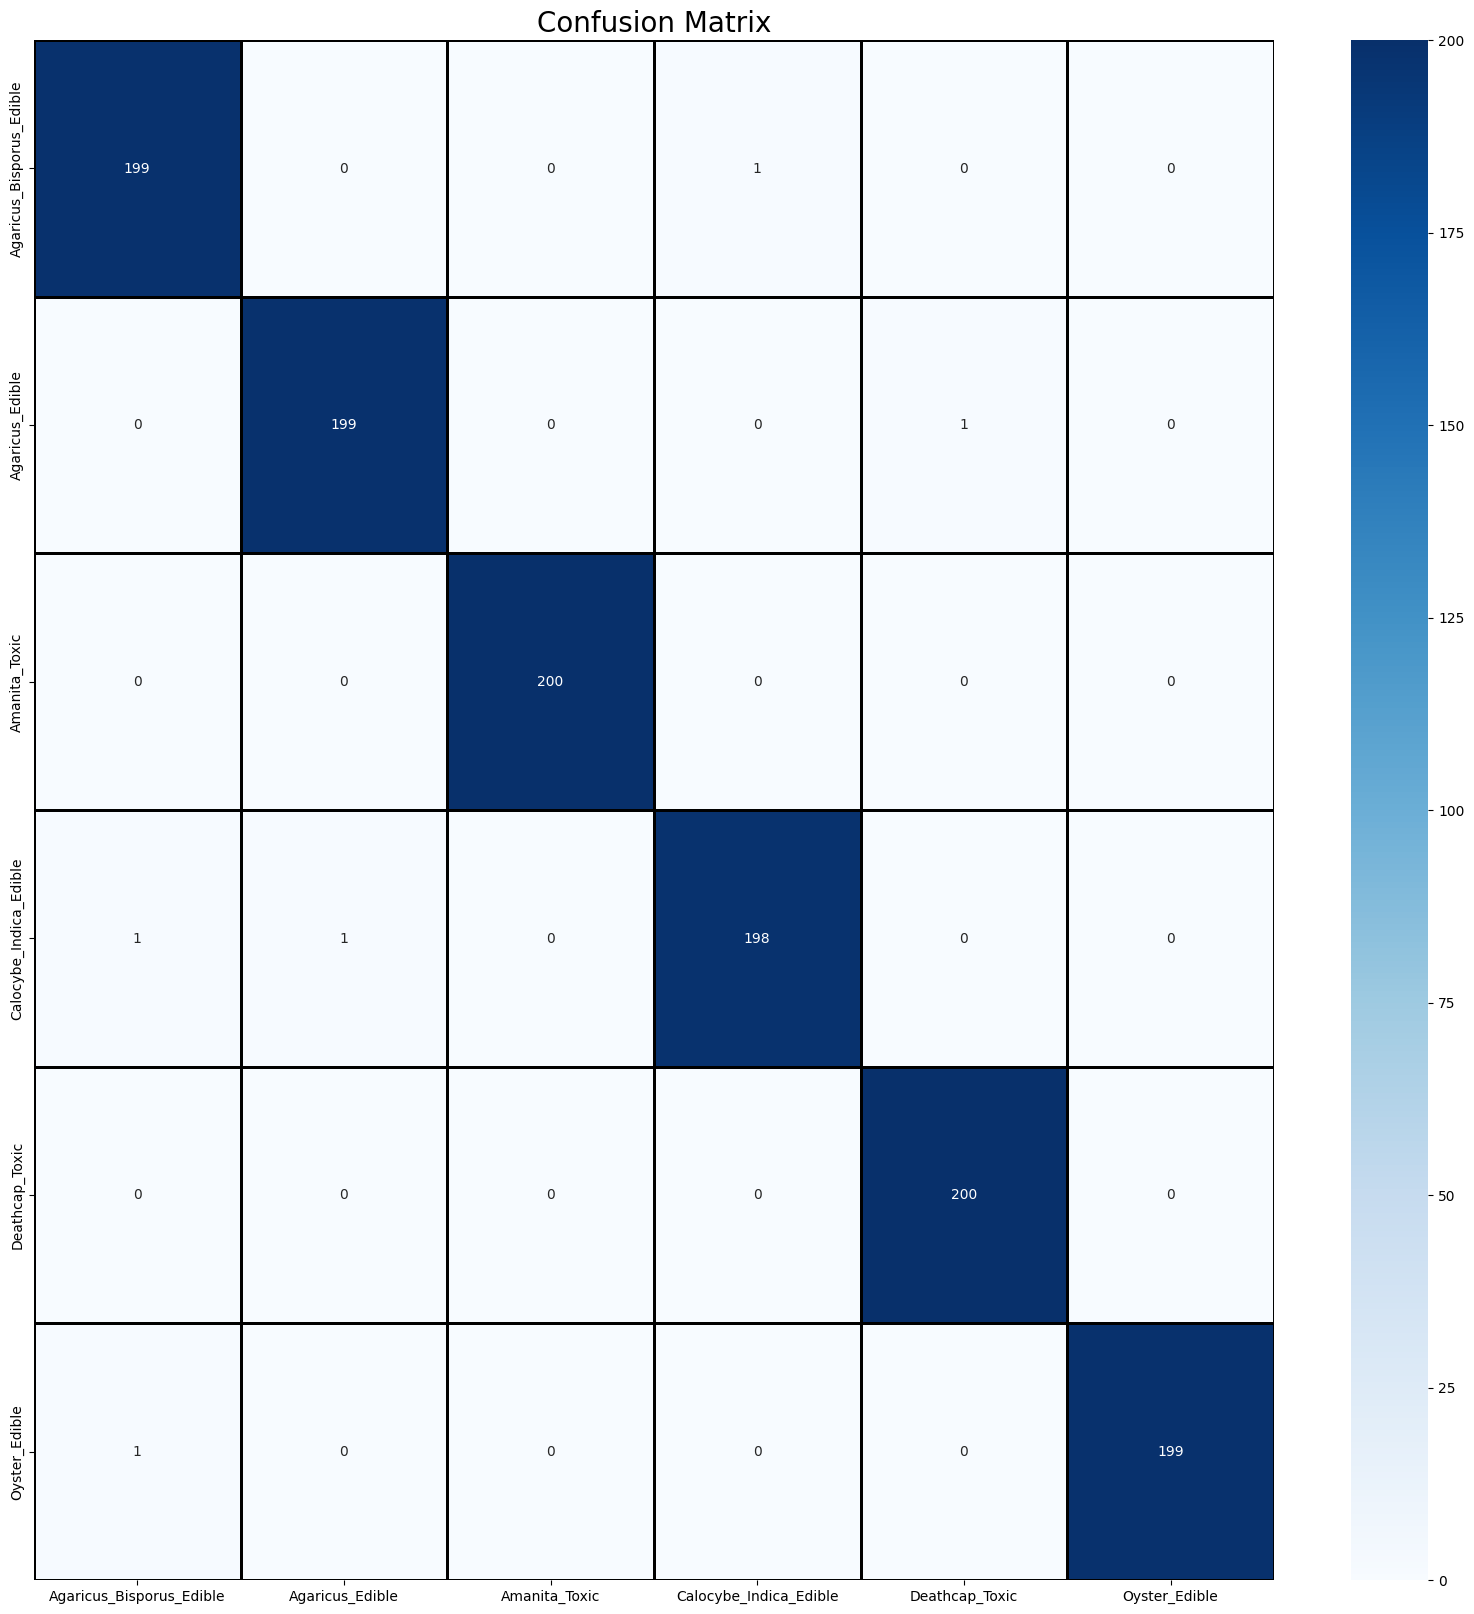

In [22]:
plt.figure(figsize = (20,20))
ct= CATEGORIES
plt.title("Confusion Matrix", fontsize =20)
sns.heatmap(cm,cmap= "Blues", linecolor = 'black' , linewidth = 1 , annot = True, fmt='',xticklabels = ct,yticklabels = ct)

In [23]:
directory = 'd:/kabbo_capstone/Dataset/saved_models/'
os.makedirs(directory, exist_ok=True)
model_json = e_model_b0.to_json()
with open(os.path.join(directory, 'enet.json'), 'w') as json_file:
    json_file.write(model_json)
weights_path = os.path.join(directory, 'efficientnet_b0_model_updated.weights.h5')
e_model_b0.save_weights(weights_path)

In [24]:
from sklearn.svm import SVC

features_train = e_model_b0.predict(X_train)
features_test = e_model_b0.predict(X_test)
features_train_flat = features_train.reshape(features_train.shape[0], -1)
features_test_flat = features_test.reshape(features_test.shape[0], -1)
svm = SVC(kernel='rbf', C=1.0, gamma='auto')
svm.fit(features_train_flat, Y_train)

188/188 ━━━━━━━━━━━━━━━━━━━━ 97s 440ms/step
38/38 ━━━━━━━━━━━━━━━━━━━━ 14s 335ms/step


SVC(gamma='auto')

In [2]:
test_accuracy = svm.score(features_test_flat, Y_test)
print("Test accuracy:", test_accuracy)

NameError: name 'svm' is not defined

In [26]:
import joblib
joblib.dump(svm, 'd:/kabbo_capstone/Dataset//saved_models/svm_model_updated.joblib')

['d:/kabbo_capstone/Dataset//saved_models/svm_model_updated.joblib']

In [27]:
print("Number of features expected by the model:", svm.n_features_in_)

Number of features expected by the model: 6


In [28]:
from sklearn.tree import DecisionTreeClassifier
y_pred = svm.predict(features_test_flat)
print(classification_report(Y_test, y_pred,digits=7,target_names = CATEGORIES))

                          precision    recall  f1-score   support

Agaricus_Bisporus_Edible  0.9900498 0.9950000 0.9925187       200
         Agaricus_Edible  0.9950000 0.9950000 0.9950000       200
           Amanita_Toxic  1.0000000 1.0000000 1.0000000       200
  Calocybe_Indica_Edible  0.9949749 0.9900000 0.9924812       200
          Deathcap_Toxic  0.9950249 1.0000000 0.9975062       200
           Oyster_Edible  1.0000000 0.9950000 0.9974937       200

                accuracy                      0.9958333      1200
               macro avg  0.9958416 0.9958333 0.9958333      1200
            weighted avg  0.9958416 0.9958333 0.9958333      1200



Precision: 0.9958415835395885
Recall: 0.9958333333333333
F1 Score: 0.9958333124998698


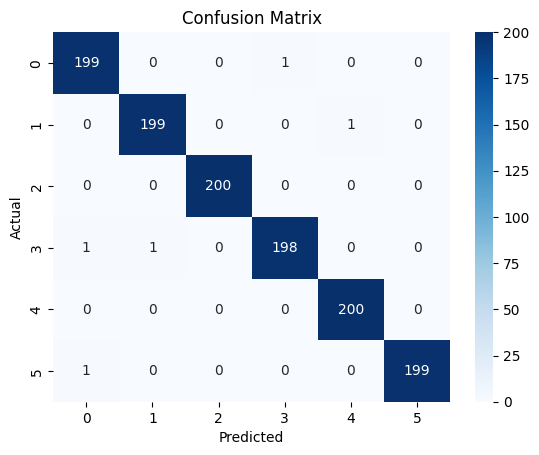

In [30]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, roc_curve, auc, confusion_matrix
import time
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score, roc_curve, confusion_matrix


# Make predictions
y_pred = svm.predict(features_test_flat)

# Calculate evaluation metrics
precision = precision_score(Y_test, y_pred, average='weighted')
recall = recall_score(Y_test, y_pred, average='weighted')
f1 = f1_score(Y_test, y_pred, average='weighted')

# Print the metrics
print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)

# Plot the confusion matrix
conf_matrix = confusion_matrix(Y_test, y_pred)
plt.figure()
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues")
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

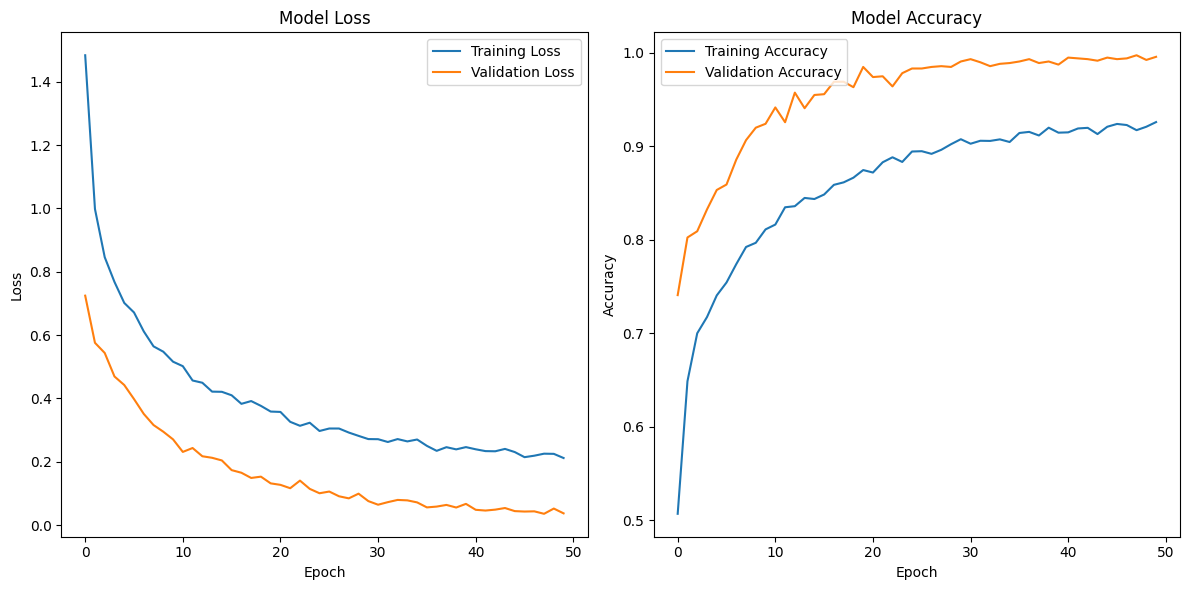

In [32]:
import matplotlib.pyplot as plt

# Retrieve the loss and accuracy history from the training process
history = efficientnet_b0.history

# Plot the training and validation loss
plt.figure(figsize=(12, 6))

# Plot training & validation loss values
plt.subplot(1, 2, 1)
plt.plot(history['loss'], label='Training Loss')
plt.plot(history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(loc='upper right')

# Plot training & validation accuracy values
plt.subplot(1, 2, 2)
plt.plot(history['accuracy'], label='Training Accuracy')
plt.plot(history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(loc='upper left')

# Display the plots
plt.tight_layout()
plt.show()
